# Handling the Anomaly Code

In [8]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import re

In [9]:
# Using custom funciton from Michael Albert's class

def summarize_dataframe(df):
    missing_values = pd.concat([pd.DataFrame(df.columns, columns=['Variable Name']), 
                      pd.DataFrame(df.dtypes.values.reshape([-1,1]), columns=['Data Type']),
                      pd.DataFrame(df.isnull().sum().values, columns=['Missing Values']), 
                      pd.DataFrame([df[name].nunique() for name in df.columns], columns=['Unique Values'])], 
                     axis=1).set_index('Variable Name')
    return pd.concat([missing_values, df.describe(include='all').transpose()], axis=1).fillna("")

In [10]:
full = pd.read_csv('/home/jovyan/MSBA Mod 5/Final Deliverable/Data Cleaning and Feature Engineering/Raw Input Files/asrs_full.csv')

In [11]:
anomalies = full.anomaly_code

In [12]:
anomalies.head(30)

0     ATC Issue All Types; Deviation / Discrepancy -...
1                Aircraft Equipment Problem Less Severe
2     Flight Deck / Cabin / Aircraft Event Illness /...
3                   Aircraft Equipment Problem Critical
4     Aircraft Equipment Problem Less Severe; Deviat...
5     Deviation / Discrepancy - Procedural Published...
6     Aircraft Equipment Problem Less Severe; Deviat...
7     ATC Issue All Types; Conflict Airborne Conflic...
8     Deviation / Discrepancy - Procedural Published...
9     Aircraft Equipment Problem Less Severe; Deviat...
10    Airspace Violation All Types; Deviation / Disc...
11    Deviation / Discrepancy - Procedural Published...
12    Conflict NMAC; Deviation / Discrepancy - Proce...
13    Aircraft Equipment Problem Critical; Flight De...
14    ATC Issue All Types; Deviation - Altitude Over...
15                  Aircraft Equipment Problem Critical
16    Aircraft Equipment Problem Less Severe; Deviat...
17    ATC Issue All Types; Deviation - Speed All

## Finding out how many and what are the unique values

In [13]:
disaggregated_anomalies = []
for phrase in anomalies:
    disaggregated_anomalies.extend([s.strip() for s in re.split(r';', phrase)])

In [14]:
disaggregated_anomalies[:30]

['ATC Issue All Types',
 'Deviation / Discrepancy - Procedural Published Material / Policy',
 'Aircraft Equipment Problem Less Severe',
 'Flight Deck / Cabin / Aircraft Event Illness / Injury',
 'Aircraft Equipment Problem Critical',
 'Aircraft Equipment Problem Less Severe',
 'Deviation / Discrepancy - Procedural Weight And Balance',
 'Deviation / Discrepancy - Procedural Published Material / Policy',
 'Deviation / Discrepancy - Procedural Weight And Balance',
 'Aircraft Equipment Problem Less Severe',
 'Deviation - Altitude Overshoot',
 'ATC Issue All Types',
 'Conflict Airborne Conflict',
 'Deviation / Discrepancy - Procedural Published Material / Policy',
 'Deviation / Discrepancy - Procedural Published Material / Policy',
 'Flight Deck / Cabin / Aircraft Event Illness / Injury',
 'Flight Deck / Cabin / Aircraft Event Smoke / Fire / Fumes / Odor',
 'Aircraft Equipment Problem Less Severe',
 'Deviation / Discrepancy - Procedural FAR',
 'Deviation / Discrepancy - Procedural Published

In [15]:
len(set(disaggregated_anomalies))

71

In [16]:
disaggregated_anomalies = pd.Series(disaggregated_anomalies)

In [17]:
value_counts = disaggregated_anomalies.value_counts().reset_index()
value_counts.columns = ["Anomaly", "Count"]

In [18]:
with pd.option_context('display.max_rows', None):
    display(value_counts)

,Anomaly,Count
0,Deviation / Discrepancy - Procedural Published...,19131
1,Aircraft Equipment Problem Critical,8227
2,Deviation / Discrepancy - Procedural Clearance,7843
3,ATC Issue All Types,6020
4,Aircraft Equipment Problem Less Severe,5605
5,Deviation / Discrepancy - Procedural FAR,3935
6,Conflict NMAC,3335
7,Inflight Event / Encounter CFTT / CFIT,3180
8,Inflight Event / Encounter Weather / Turbulence,2878
9,Deviation - Track / Heading All Types,2374


/tmp/ipykernel_3806/2495579317.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


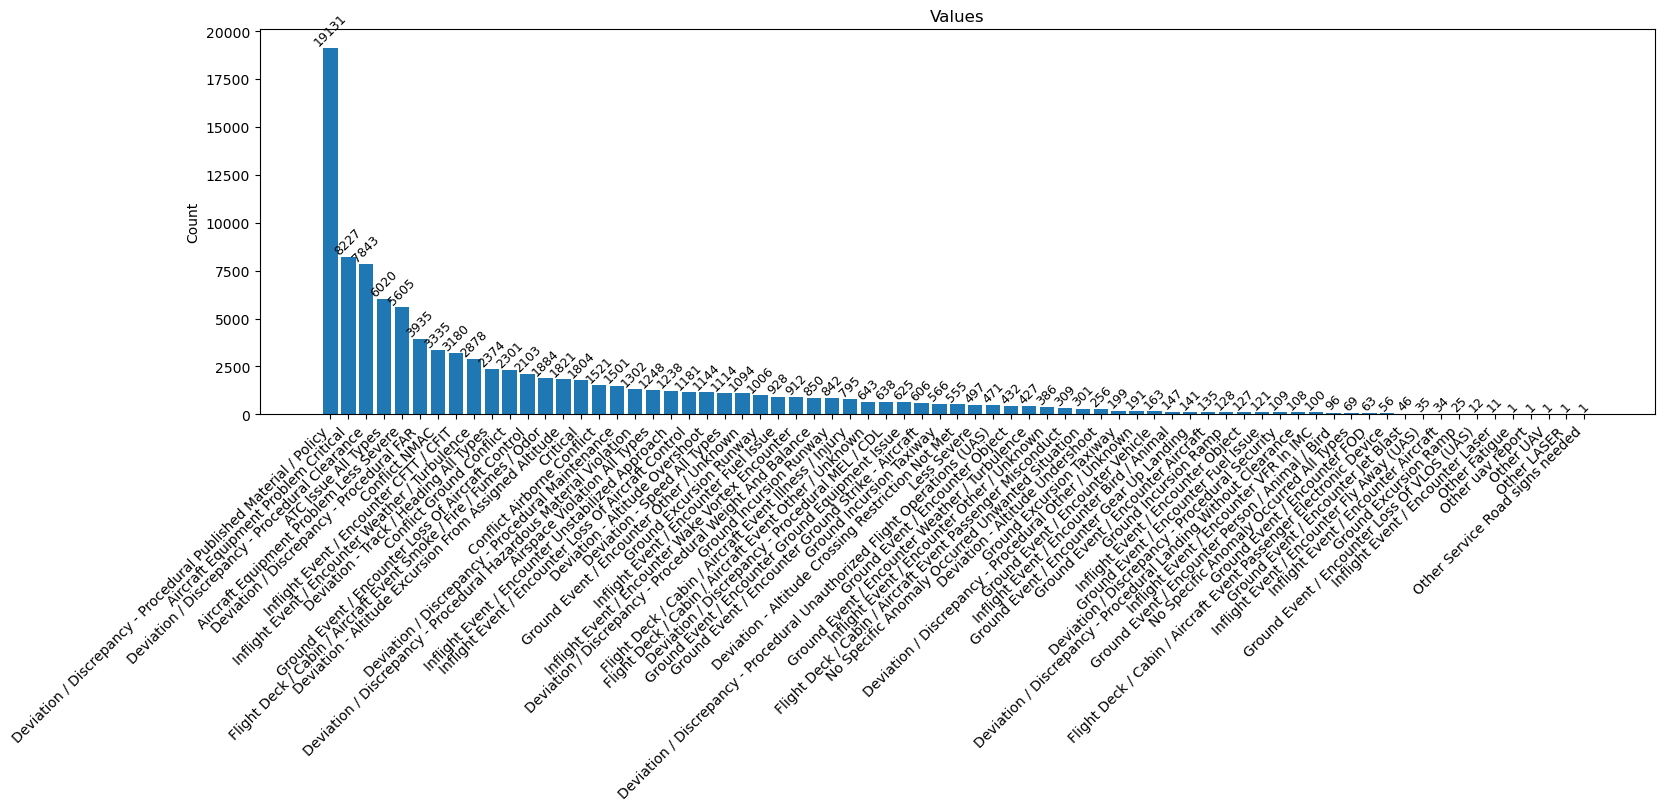

In [19]:
x = value_counts['Anomaly']
y = value_counts['Count']

fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(x,y)

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        int(bar.get_height()),
        ha='center', va='bottom', fontsize=9, rotation =45
    )

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('Values')
ax.set_ylabel('Count')
plt.show()

## Creating Dummy Columns Manually

In [20]:
# Create Dummy Columns

# create a copy of the data

# loop to create the columns, set default to 0
# for anomaly in disaggregated_anomalies:
  #  dummy_full[anomaly] = 0

# pd.set_option('display.max_rows', None)

# summarize_dataframe(dummy_full)

In [21]:
# dummy_full['anomaly_code'].apply(dummy_code(dummy_full))

In [22]:
# dummy_full['anomaly_code'] = dummy_full['anomaly_code'].str.replace(' ', '', regex=False)
# or, to only strip edges of each value:
# dummy_full['anomaly_code'] = dummy_full['anomaly_code'].apply(
    # lambda x: ';'.join(v.strip() for v in x.split(';')) if isinstance(x, str) else x
# )


## Getting Dummy Columns the Easy Way

In [23]:
dummy_full = full.copy()
dummy_full['anomaly_code'] = dummy_full['anomaly_code'].str.replace(' ', '', regex=False)
dummies = dummy_full['anomaly_code'].str.get_dummies(sep=';')
dummy_full = pd.concat([full.copy(), dummies], axis=1)

In [24]:
with pd.option_context('display.max_rows', None):
    display(summarize_dataframe(dummy_full))

/tmp/ipykernel_3806/1810182620.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return pd.concat([missing_values, df.describe(include='all').transpose()], axis=1).fillna("")


,Data Type,Missing Values,Unique Values,count,unique,top,freq,mean,std,min,25%,50%,75%,max
acn,int64,0,33723,33723.0,,,,1828811.478783,192110.173434,1507557.0,1673862.5,1806271.0,1981117.5,2296796.0
event_date,object,0,84,33723.0,84,2019-11-01,622,,,,,,,
anomaly_code,object,0,6664,33723.0,6664,Aircraft Equipment Problem Critical,1974,,,,,,,
location_id,object,0,1903,33723.0,1903,ZZZ.Airport,15229,,,,,,,
aircraft_type,object,35,554,33688.0,554,Commercial Fixed Wing,4791,,,,,,,
reporter_function,object,284,563,33439.0,563,Captain; Pilot Flying,4760,,,,,,,
flight_phase,object,903,347,32820.0,347,Cruise,5064,,,,,,,
narrative_text,object,0,33715,33723.0,33715,The UAS lost the telemetry link 1;300 feet fro...,3,,,,,,,
synopsis,object,1,33668,33722.0,33668,Part 107 UAS pilot reported flying in controll...,9,,,,,,,
word_count,int64,0,1306,33723.0,,,,261.27207,216.912553,2.0,119.0,205.0,334.0,2345.0


In [25]:
print(dummy_full.columns[-72:])

Index(['label_method', 'ATCIssueAllTypes', 'AircraftEquipmentProblemCritical',
       'AircraftEquipmentProblemLessSevere', 'AirspaceViolationAllTypes',
       'ConflictAirborneConflict', 'ConflictGroundConflict', 'ConflictNMAC',
       'Critical', 'Deviation-AltitudeCrossingRestrictionNotMet',
       'Deviation-AltitudeExcursionFromAssignedAltitude',
       'Deviation-AltitudeOvershoot', 'Deviation-AltitudeUndershoot',
       'Deviation-SpeedAllTypes', 'Deviation-Track/HeadingAllTypes',
       'Deviation/Discrepancy-ProceduralClearance',
       'Deviation/Discrepancy-ProceduralFAR',
       'Deviation/Discrepancy-ProceduralHazardousMaterialViolation',
       'Deviation/Discrepancy-ProceduralLandingWithoutClearance',
       'Deviation/Discrepancy-ProceduralMEL/CDL',
       'Deviation/Discrepancy-ProceduralMaintenance',
       'Deviation/Discrepancy-ProceduralOther/Unknown',
       'Deviation/Discrepancy-ProceduralPublishedMaterial/Policy',
       'Deviation/Discrepancy-ProceduralSecurit

In [26]:
dummy_full.head(30)

,acn,event_date,anomaly_code,location_id,aircraft_type,reporter_function,flight_phase,narrative_text,synopsis,word_count,...,InflightEvent/EncounterWakeVortexEncounter,InflightEvent/EncounterWeather/Turbulence,LessSevere,NoSpecificAnomalyOccurredAllTypes,NoSpecificAnomalyOccurredUnwantedSituation,OtherFatigue,OtherLASER,OtherServiceRoadsignsneeded,OtherUAV,Otheruavreport
0,1507557,2018-01-01,ATC Issue All Types; Deviation / Discrepancy -...,C90.TRACON,A330,Approach,Landing,Aircraft X was assigned a runway approximately...,MLI Approach Controller reported ATC denied th...,143,...,0,0,0,0,0,0,0,0,0,0
1,1513720,2018-01-01,Aircraft Equipment Problem Less Severe,ZZZ.Airport,EMB ERJ 170/175 ER/LR,Captain; Pilot Not Flying,Cruise,Pack 2 was MELed. My FO (First Officer) and I ...,ERJ-175 Captain reported diverting after exper...,318,...,0,0,0,0,0,0,0,0,0,0
2,1513718,2018-01-01,Flight Deck / Cabin / Aircraft Event Illness /...,ZZZ.ARTCC,A321,Pilot Not Flying,Cruise,[A passenger] was reported as being ill and un...,A321 flight crew member reported difficulty re...,166,...,0,0,0,0,0,0,0,0,0,0
3,1513706,2018-01-01,Aircraft Equipment Problem Critical,ZZZ.Airport,Citation V/Ultra/Encore (C560),First Officer; Pilot Flying,Final Approach,While on approach at 1;500ft; we asked the tow...,CE-560 First Officer reported that while on ap...,268,...,0,0,0,0,0,0,0,0,0,0
4,1513663,2018-01-01,Aircraft Equipment Problem Less Severe; Deviat...,RCTP.Airport,B747-400,Pilot Flying; Captain,NaN,Our aircraft had just finished a 'heavy' maint...,B747-400 Captain reported a loss of hydraulic ...,190,...,0,0,0,0,0,0,0,0,0,0
5,1513655,2018-01-01,Deviation / Discrepancy - Procedural Published...,YSSY.Airport,Large Transport; Low Wing; 2 Turbojet Eng,Pilot Not Flying; Captain,Parked,Had printed; acknowledged and signed Release 1...,Air carrier Captain reported a breakdown in co...,334,...,0,0,0,0,0,0,0,0,0,0
6,1513614,2018-01-01,Aircraft Equipment Problem Less Severe; Deviat...,ZZZ.Airport,B737-700,First Officer; Pilot Flying,Climb,Climbing out on the Departure; the FO (First O...,B737-700 flight crew reported overshooting the...,130,...,0,0,0,0,0,0,0,0,0,0
7,1513606,2018-01-01,ATC Issue All Types; Conflict Airborne Conflic...,MWH.Tower,Globemaster (C-17),Approach; Departure; Supervisor / CIC,Initial Approach,I was working CIC (Controller In Charge) along...,MWH Tower Cab Radar Controller In Charge repor...,631,...,0,0,0,0,0,0,0,0,0,0
8,1513600,2018-01-01,Deviation / Discrepancy - Procedural Published...,ZZZ.Airport,A330,Flight Attendant (On Duty),Initial Approach; Initial Climb,On takeoff I smelled fumes that had a sweet ch...,A330 cabin crew reported smelling an odd odor ...,221,...,0,0,0,0,0,0,0,0,0,0
9,1513569,2018-01-01,Aircraft Equipment Problem Less Severe; Deviat...,SLE.Airport,Baron 58/58TC,Pilot Flying; Captain,Landing,Lack of runway control after landing Runway 16...,GA pilot reported loss of directional control ...,41,...,0,0,0,0,0,0,0,0,0,0


In [27]:
len(dummy_full.columns)

91

In [28]:
# Filtering the columns for better viewability

dummy_ID = dummy_full[['acn', 'anomaly_code']]
dummy_cats = dummy_full.iloc[:, -72:]
dummy_cut = pd.concat([dummy_ID, dummy_cats], axis=1)

In [29]:
len(dummy_cut.columns)

74

In [30]:
with pd.option_context('display.max_columns', None,
                        'display.max_colwidth', None,
                        'display.width', None):
    display(dummy_cut.head(25))


,acn,anomaly_code,label_method,ATCIssueAllTypes,AircraftEquipmentProblemCritical,AircraftEquipmentProblemLessSevere,AirspaceViolationAllTypes,ConflictAirborneConflict,ConflictGroundConflict,ConflictNMAC,Critical,Deviation-AltitudeCrossingRestrictionNotMet,Deviation-AltitudeExcursionFromAssignedAltitude,Deviation-AltitudeOvershoot,Deviation-AltitudeUndershoot,Deviation-SpeedAllTypes,Deviation-Track/HeadingAllTypes,Deviation/Discrepancy-ProceduralClearance,Deviation/Discrepancy-ProceduralFAR,Deviation/Discrepancy-ProceduralHazardousMaterialViolation,Deviation/Discrepancy-ProceduralLandingWithoutClearance,Deviation/Discrepancy-ProceduralMEL/CDL,Deviation/Discrepancy-ProceduralMaintenance,Deviation/Discrepancy-ProceduralOther/Unknown,Deviation/Discrepancy-ProceduralPublishedMaterial/Policy,Deviation/Discrepancy-ProceduralSecurity,Deviation/Discrepancy-ProceduralUnauthorizedFlightOperations(UAS),Deviation/Discrepancy-ProceduralWeightAndBalance,FlightDeck/Cabin/AircraftEventIllness/Injury,FlightDeck/Cabin/AircraftEventOther/Unknown,FlightDeck/Cabin/AircraftEventPassengerElectronicDevice,FlightDeck/Cabin/AircraftEventPassengerMisconduct,FlightDeck/Cabin/AircraftEventSmoke/Fire/Fumes/Odor,GroundEvent/EncounterAircraft,GroundEvent/EncounterFOD,GroundEvent/EncounterFuelIssue,GroundEvent/EncounterGearUpLanding,GroundEvent/EncounterGroundEquipmentIssue,GroundEvent/EncounterGroundStrike-Aircraft,GroundEvent/EncounterJetBlast,GroundEvent/EncounterLossOfAircraftControl,GroundEvent/EncounterLossOfVLOS(UAS),GroundEvent/EncounterObject,GroundEvent/EncounterOther/Unknown,GroundEvent/EncounterPerson/Animal/Bird,GroundEvent/EncounterVehicle,GroundEvent/EncounterWeather/Turbulence,GroundExcursionRamp,GroundExcursionRunway,GroundExcursionTaxiway,GroundIncursionRamp,GroundIncursionRunway,GroundIncursionTaxiway,InflightEvent/EncounterAircraft,InflightEvent/EncounterBird/Animal,InflightEvent/EncounterCFTT/CFIT,InflightEvent/EncounterFlyAway(UAS),InflightEvent/EncounterFuelIssue,InflightEvent/EncounterLaser,InflightEvent/EncounterLossOfAircraftControl,InflightEvent/EncounterObject,InflightEvent/EncounterOther/Unknown,InflightEvent/EncounterUnstabilizedApproach,InflightEvent/EncounterVFRInIMC,InflightEvent/EncounterWakeVortexEncounter,InflightEvent/EncounterWeather/Turbulence,LessSevere,NoSpecificAnomalyOccurredAllTypes,NoSpecificAnomalyOccurredUnwantedSituation,OtherFatigue,OtherLASER,OtherServiceRoadsignsneeded,OtherUAV,Otheruavreport
0,1507557,ATC Issue All Types; Deviation / Discrepancy - Procedural Published Material / Policy,exact_anomaly_code_same_location_12mo,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1513720,Aircraft Equipment Problem Less Severe,exact_anomaly_code_same_location_12mo,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1513718,Flight Deck / Cabin / Aircraft Event Illness / Injury,exact_anomaly_code_same_location_12mo,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1513706,Aircraft Equipment Problem Critical,exact_anomaly_code_same_location_12mo,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,1513663,Aircraft Equipment Problem Less Severe; Deviation / Discrepancy - Procedural Weight And Balance,exact_anomaly_code_same_location_12mo,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,1513655,Deviation / Discrepancy - Procedural Published Material / Policy; Deviation / Discrepancy - Procedural Weight And Balance,exact_anomaly_code_same_location_12mo,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

In [31]:
columns = dummy_full.columns.to_list()
columns

['acn',
 'event_date',
 'anomaly_code',
 'location_id',
 'aircraft_type',
 'reporter_function',
 'flight_phase',
 'narrative_text',
 'synopsis',
 'word_count',
 'hedge_score',
 'passive_voice_ratio',
 'causal_connective_count',
 'specificity_score',
 'named_entity_count',
 'type_token_ratio',
 'recurrence_flag',
 'days_to_recurrence',
 'is_right_censored',
 'label_method',
 'ATCIssueAllTypes',
 'AircraftEquipmentProblemCritical',
 'AircraftEquipmentProblemLessSevere',
 'AirspaceViolationAllTypes',
 'ConflictAirborneConflict',
 'ConflictGroundConflict',
 'ConflictNMAC',
 'Critical',
 'Deviation-AltitudeCrossingRestrictionNotMet',
 'Deviation-AltitudeExcursionFromAssignedAltitude',
 'Deviation-AltitudeOvershoot',
 'Deviation-AltitudeUndershoot',
 'Deviation-SpeedAllTypes',
 'Deviation-Track/HeadingAllTypes',
 'Deviation/Discrepancy-ProceduralClearance',
 'Deviation/Discrepancy-ProceduralFAR',
 'Deviation/Discrepancy-ProceduralHazardousMaterialViolation',
 'Deviation/Discrepancy-Procedura

In [32]:
# This looks finished, but we may opt to lump all the "other" categories into a single "other" cateogry